# Exploratory Data Analysis (EDA)

## Objetivo:
Explorar la composición del microbioma intestinal, la distribución de condiciones clínicas y posibles sesgos asociados a metadata como país, estudio, edad, género y BMI.

## 0. Importar librerías

In [14]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


## 1. Cargar datos limpios

In [9]:
df_eda = pd.read_csv("D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/data/processed/abundance_stoolsubset_clean.csv",
    low_memory=False
)

df_eda.shape

(1577, 2135)

## 2. Vista general del dataset

In [10]:
metadata_cols = [
    "dataset_name",
    "sampleID",
    "disease",
    "age",
    "gender",
    "country",
    "bmi"
]

taxa_cols = [col for col in df_eda.columns if col.startswith("k__")]

print("Número de muestras:", df_eda.shape[0])
print("Número de columnas totales:", df_eda.shape[1])
print("Número de columnas metadata:", len(metadata_cols))
print("Número de columnas taxonómicas:", len(taxa_cols))

Número de muestras: 1577
Número de columnas totales: 2135
Número de columnas metadata: 7
Número de columnas taxonómicas: 2128


In [11]:
df_eda[metadata_cols].isna().sum().sort_values(ascending=False)

age             356
bmi             331
dataset_name      0
disease           0
sampleID          0
gender            0
country           0
dtype: int64

In [12]:
df_eda["sampleID"].duplicated().sum()

np.int64(0)

In [13]:
df_eda["disease"].value_counts(dropna=False)

disease
n                             710
t2d                           223
ibd_ulcerative_colitis        148
cirrhosis                     118
obesity                        75
impaired_glucose_tolerance     49
cancer                         48
n_relative                     47
stec2-positive                 43
leanness                       42
small_adenoma                  26
ibd_crohn_disease              25
large_adenoma                  13
overweight                     10
Name: count, dtype: int64

El dataset limpio contiene **1577 muestras únicas**, sin sampleID duplicados y con **2128 variables taxonómicas**. La variable disease no presenta valores nulos, aunque age y bmi conservan valores faltantes, por lo que inicialmente se utilizarán como variables descriptivas y no como predictores principales.

## 3. Distribución de las enfermedades

In [44]:
# Conteo y porcentaje por enfermedad
disease_counts = df_eda["disease"].value_counts().sort_values(ascending=False)
disease_percentages = disease_counts / disease_counts.sum() * 100

In [45]:
# DataFrame - conteo y porcentaje por enfermedad
disease_distribution = pd.DataFrame({
    "count": disease_counts,
    "percentage": disease_percentages.round(2)
})

disease_distribution

,count,percentage
disease,,
n,710,45.02
t2d,223,14.14
ibd_ulcerative_colitis,148,9.38
cirrhosis,118,7.48
obesity,75,4.76
impaired_glucose_tolerance,49,3.11
cancer,48,3.04
n_relative,47,2.98
stec2-positive,43,2.73


In [46]:
### Paleta de colores

# Paleta general del proyecto
project_palette = {
    "primary": "#2F5D62",
    "secondary": "#5E8B7E",
    "accent": "#D88C3A",
    "danger": "#B85750",
    "neutral": "#6B7280",
    "light": "#F3F4F6",
    "dark": "#1F2937"
}

# Paleta específica para "disease"
disease_palette = {
    "n": "#2F5D62",
    "t2d": "#D88C3A",
    "ibd_ulcerative_colitis": "#7A5195",
    "cirrhosis": "#B85750",
    "obesity": "#5E8B7E",
    "impaired_glucose_tolerance": "#E0A458",
    "cancer": "#4C78A8",
    "n_relative": "#8C8C8C",
    "stec2-positive": "#C44E52",
    "leanness": "#76B7B2",
    "small_adenoma": "#9C755F",
    "ibd_crohn_disease": "#59A14F",
    "large_adenoma": "#AF7AA1",
    "overweight": "#F28E2B"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\3968542494.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


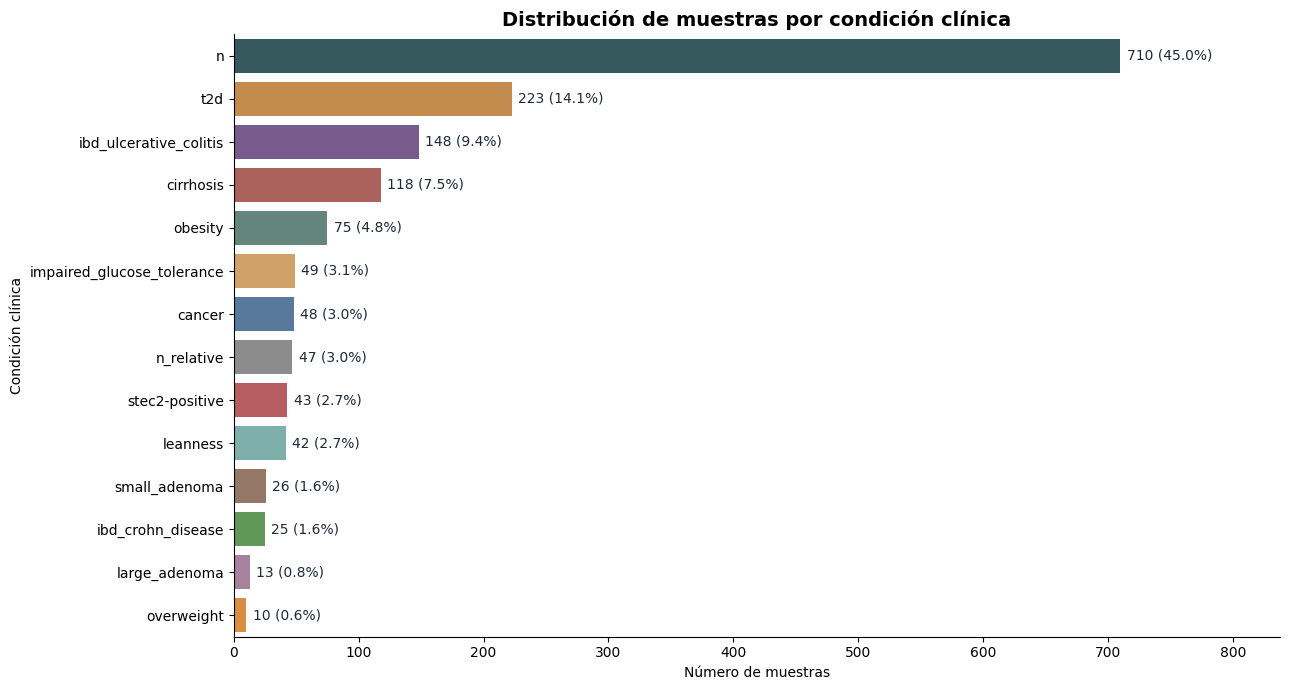

In [49]:
## Gráfico de barras - distribución de enfermedades
plt.figure(figsize=(13, 7))

bar_colors = [
    disease_palette.get(disease, project_palette["neutral"])
    for disease in disease_counts.index
]

ax = sns.barplot(
    x=disease_counts.values,
    y=disease_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(disease_counts.values, disease_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("Condición clínica")
plt.xlim(0, disease_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/muestra_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

La variable `disease` presenta una distribución desbalanceada. 
<br>
La clase mayoritaria es `n`, correspondiente a controles, seguida por `t2d`, `ibd_ulcerative_colitis`, `cirrhosis` y `obesity`.
<br>
Algunas categorías tienen muy pocas muestras, como `large_adenoma` y `overweight`, por lo que se conservarán para EDA general pero no se consideran candidatas principales para el modelado supervisado inicial.

## 4. Análisis de metadata clínica

### 4.1. Distribución de `age` y `bmi`

In [52]:
numeric_metadata = ["age", "bmi"]

df_eda[numeric_metadata].describe()

,age,bmi
count,1221.000000,1246.000000
mean,48.964955,24.534551
std,16.445743,4.665831
min,2.000000,14.050000
25%,37.000000,21.000000
50%,49.000000,24.000000
75%,63.000000,26.875000
max,89.000000,46.600000


In [ ]:
# Porcentaje de valores nulos en "age" y "bmi"
missing_numeric_metadata = (
    df_eda[numeric_metadata]
    .isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_numeric_metadata

age    22.57
bmi    20.99
dtype: float64

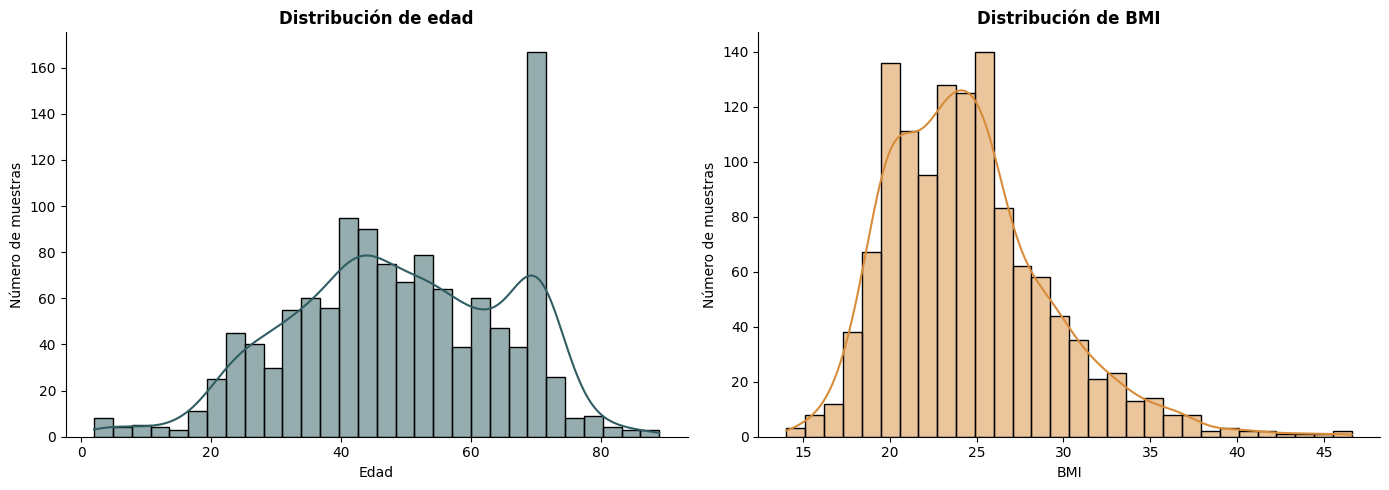

In [51]:
# Distribución general de "age" y "bmi"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))     # dos gráficos en una fila

# Age
sns.histplot(
    data=df_eda,
    x="age",
    bins=30,        # 30 grupos
    kde=True,       # curva suave de densidad
    color=project_palette["primary"],
    ax=axes[0]
)

axes[0].set_title("Distribución de edad", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Número de muestras")

# BMI
sns.histplot(
    data=df_eda,
    x="bmi",
    bins=30,
    kde=True,
    color=project_palette["accent"],
    ax=axes[1]
)

axes[1].set_title("Distribución de BMI", fontsize=12, fontweight="bold")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Número de muestras")

sns.despine()       # quit alos bordes visuales del gráfico
plt.tight_layout()  # evita que los textos y ejes se monten

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/distr_edad_bmi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Seleccionar enfermedades con al menos 40 muestras
min_samples = 40

disease_counts = df_eda["disease"].value_counts()
diseases_for_boxplot = disease_counts[disease_counts >= min_samples].index

df_boxplot = df_eda[df_eda["disease"].isin(diseases_for_boxplot)].copy()

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\2205178872.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


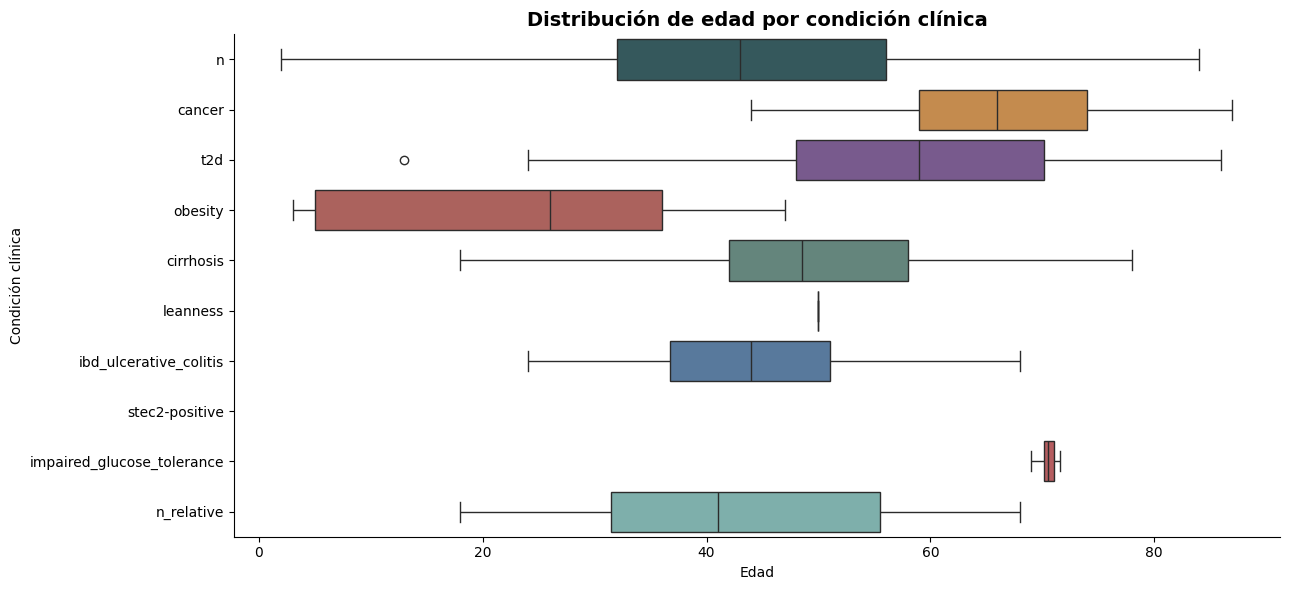

In [41]:
## Boxplot de edad por enfermedad
plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df_boxplot,
    x="age",
    y="disease",
    palette=[
        disease_palette.get(disease, project_palette["neutral"])
        for disease in diseases_for_boxplot
    ]
)

plt.title("Distribución de edad por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("Edad")
plt.ylabel("Condición clínica")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/edad_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\1687445266.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


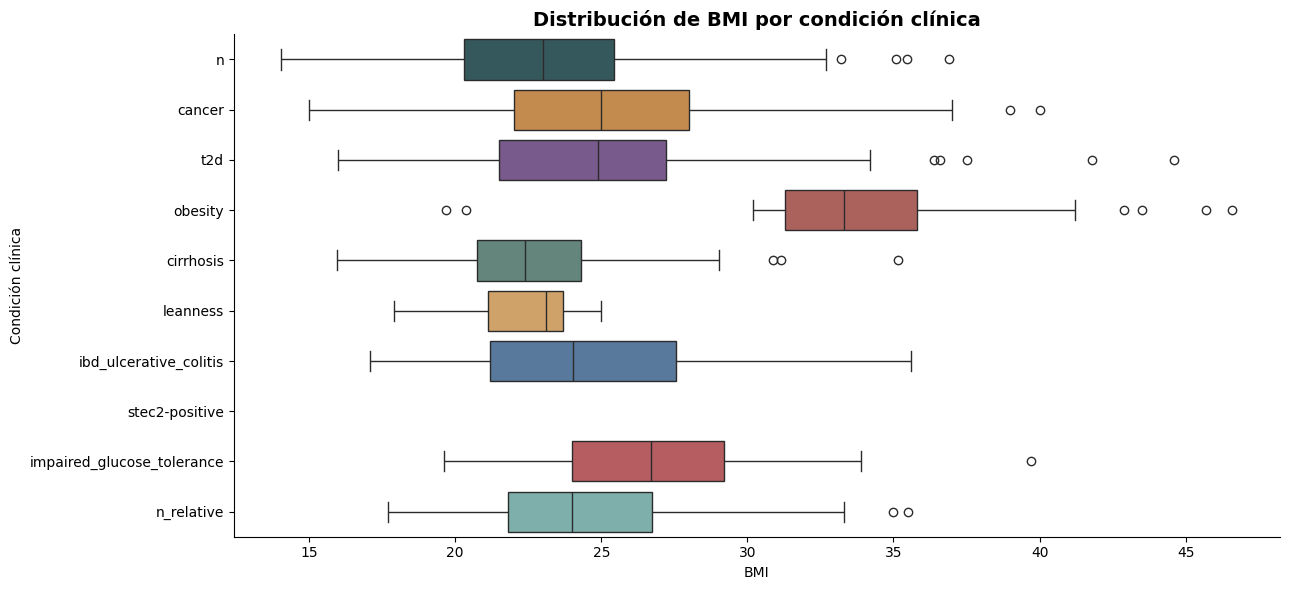

In [ ]:
## Boxplot de BMI por enfermedad
plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df_boxplot,
    x="bmi",
    y="disease",
    palette=[
        disease_palette.get(disease, project_palette["neutral"])
        for disease in diseases_for_boxplot
    ]
)

plt.title("Distribución de BMI por condición clínica", fontsize=14, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Condición clínica")

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/bmi_condicion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Distribución de metadata categórica

### 5.1. Distribución de metadata categórica: `gender`

In [53]:
# Conteo de muestras por categoria de "gender" (male/female/unknown)
gender_counts = df_eda["gender"].value_counts()

# Porcentaje que representa cada categoría
gender_percentages = gender_counts / gender_counts.sum() * 100

# DataFrame - conteo y porcentaje
gender_distribution = pd.DataFrame({
    "count": gender_counts,
    "percentage": gender_percentages.round(2)
})

gender_distribution

,count,percentage
gender,,
male,688,43.63
female,585,37.10
unknown,304,19.28


In [59]:
# Paleta de colores
gender_palette = {
    "female": "#2F5D62",
    "male": "#D88C3A",
    "unknown": "#8C8C8C"
}

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\3367694956.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


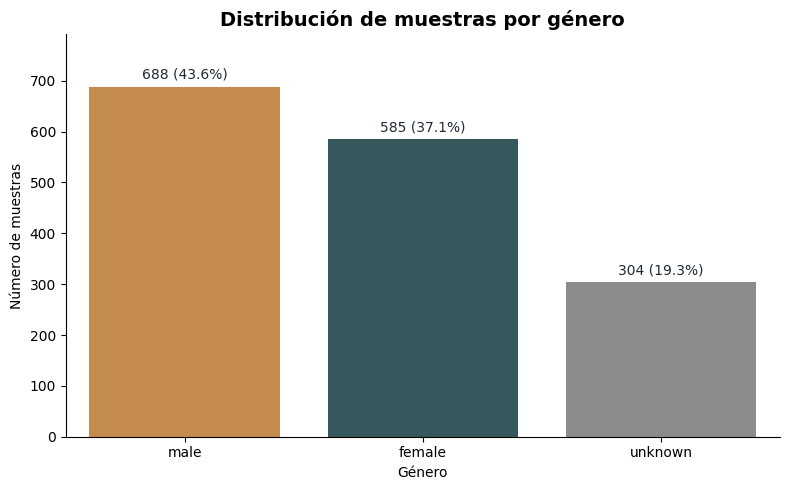

In [60]:
# Gráfico
plt.figure(figsize=(8, 5))

bar_colors = [
    gender_palette.get(gender, project_palette["neutral"])
    for gender in gender_counts.index
]

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(gender_counts.values, gender_percentages.values)):
    ax.text(
        i,
        count + 10,
        f"{count} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por género", fontsize=14, fontweight="bold")
plt.xlabel("Género")
plt.ylabel("Número de muestras")
plt.ylim(0, gender_counts.max() * 1.15)

sns.despine()
plt.tight_layout()

plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/genero_distr",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.2. Distribución de metadata categórica: `country`

In [69]:
# Distribución por país: top 10 + "other" + "unknown"

country_counts = df_eda["country"].value_counts()

# Seleccionar top 10 países, excluyendo "unknown"
top_n_countries = 10

top_countries = (
    country_counts
    .drop(labels="unknown", errors="ignore")
    .head(top_n_countries)
    .index
    .tolist()
)

# Crear una columna auxiliar para el gráfico
df_eda["country_plot"] = df_eda["country"].where(
    df_eda["country"].isin(top_countries),
    "other"
)

# Mantener "unknown" separado, no dentro de "other"
df_eda.loc[df_eda["country"] == "unknown", "country_plot"] = "unknown"

# Conteos y porcentajes
country_plot_counts = df_eda["country_plot"].value_counts()

# Orden manual: top 10 países, luego "other", luego "unknown"
country_order = top_countries.copy()

if "other" in country_plot_counts.index:
    country_order.append("other")

if "unknown" in country_plot_counts.index:
    country_order.append("unknown")

country_plot_counts = country_plot_counts.loc[country_order]
country_plot_percentages = country_plot_counts / country_plot_counts.sum() * 100

In [70]:
# Paleta para países
country_palette_base = [
    project_palette["primary"],
    project_palette["secondary"],
    "#4C78A8",
    "#7A5195",
    "#76B7B2",
    "#E0A458",
    "#9C755F",
    "#59A14F",
    "#AF7AA1",
    "#F28E2B"
]

country_palette = {
    country: color
    for country, color in zip(top_countries, country_palette_base)
}

country_palette["other"] = project_palette["accent"]
country_palette["unknown"] = "#9CA3AF"

bar_colors = [
    country_palette.get(country, project_palette["neutral"])
    for country in country_plot_counts.index
]

C:\Users\gonza\AppData\Local\Temp\ipykernel_11700\2596293868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


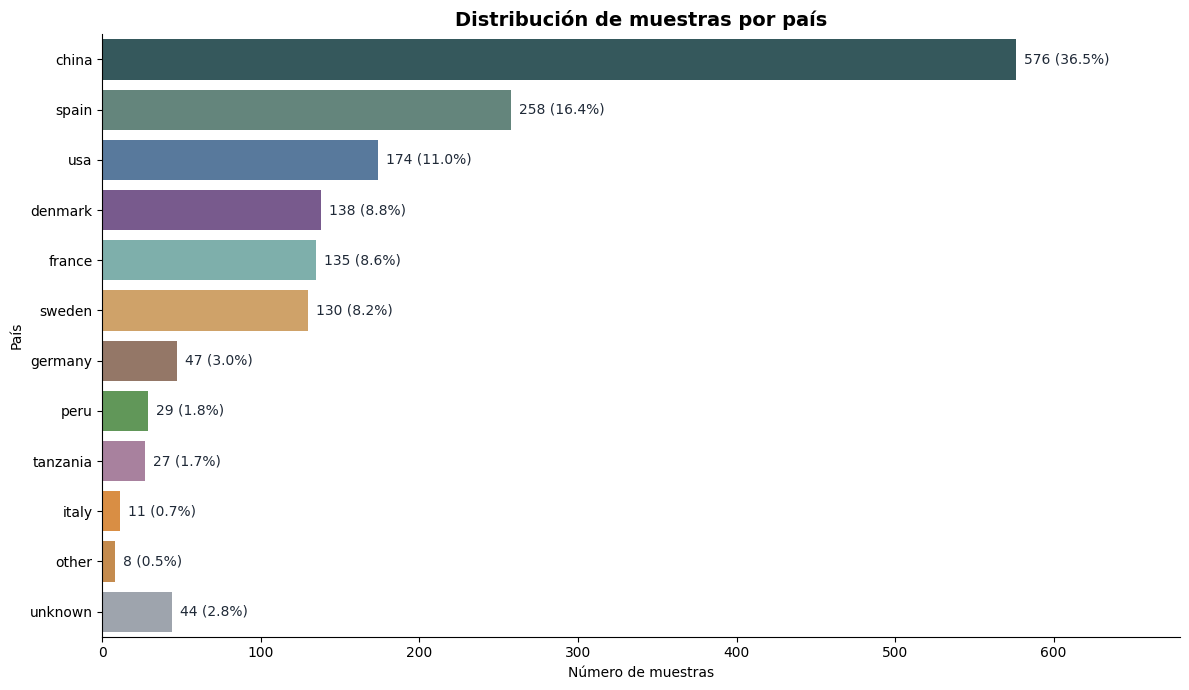

In [71]:
# Gráfico
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=country_plot_counts.values,
    y=country_plot_counts.index,
    palette=bar_colors
)

for i, (count, pct) in enumerate(zip(country_plot_counts.values, country_plot_percentages.values)):
    ax.text(
        count + 5,
        i,
        f"{count} ({pct:.1f}%)",
        va="center",
        fontsize=10,
        color=project_palette["dark"]
    )

plt.title("Distribución de muestras por país", fontsize=14, fontweight="bold")
plt.xlabel("Número de muestras")
plt.ylabel("País")
plt.xlim(0, country_plot_counts.max() * 1.18)

sns.despine()
plt.tight_layout()

# Guardar gráfico
plt.savefig(
    f"D:/BOOTCAMP/CARPETA_BARBARA/ML_MICROBIOME/ML/docs/figures/country_distr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.3. Distribución de metadata categórica: `dataset_name`

Observar si el dataset está dominado por ciertos estudios. Y eso importa muchísimo, porque si luego el PCA o el modelo separan por `dataset_name`, puedeb haber sesgo de origen.

In [72]:
# Distribución por dataset de origen

# Contar cuántas muestras vienen de cada "dataset_name"
dataset_counts = df_eda["dataset_name"].value_counts()

# Calcular porcentaje
dataset_percentages = dataset_counts / dataset_counts.sum() * 100

# Top 20 estudios/datasets principales
dataset_distribution = pd.DataFrame({
    "count": dataset_counts,
    "percentage": dataset_percentages.round(2)
})

dataset_distribution.head(20)

,count,percentage
dataset_name,,
t2dmeta_long,271,17.18
quin_gut_liver_cirrhosis,232,14.71
neilsen_genome_assembly,231,14.65
hmp,152,9.64
wt2d,145,9.19
zeller_fecal_colorectal_cancer,134,8.50
chatelier_gut_obesity,115,7.29
t2dmeta_short,73,4.63
tito_subsistence_gut,51,3.23
